# Notebook 03 — Word Embeddings (Word2Vec)

## Overview
This notebook demonstrates **Technique 2: Word Embedding Methods** using **Word2Vec** (Mikolov et al., 2013), trained on our cleaned movie text corpus.

## What are Word Embeddings?
Word embeddings are dense numerical vectors that represent words in a high-dimensional space. Words with similar meanings are placed close together. For example:
- `king - man + woman ≈ queen`
- `action` and `adventure` should have high cosine similarity

## Word2Vec — How It Works
Word2Vec uses a shallow neural network trained on a sliding window of words (context window). Two architectures exist:
- **CBOW (Continuous Bag of Words):** Predicts a word from its context
- **Skip-gram:** Predicts context words from a target word (used here)

**Hyperparameters used:**
| Parameter | Value | Meaning |
|-----------|-------|----------|
| `vector_size` | 100 | Each word → 100-dimensional vector |
| `window` | 5 | Look at 5 words either side |
| `min_count` | 1 | Include all words |
| `epochs` | 10 | Train for 10 passes over the data |

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from src.embeddings import run_embeddings_pipeline, get_movie_vector

plt.style.use('dark_background')
print('Libraries loaded.')

Libraries loaded.


## 1. Train Word2Vec and Build Movie Vectors

We train Word2Vec on all 4,803 movie text descriptions. After training, each movie is represented as the **average of all its word vectors** — this gives us one fixed-size vector per movie, regardless of text length.

In [2]:
df, w2v_model, movie_matrix = run_embeddings_pipeline()
print(f'Vocabulary size: {len(w2v_model.wv)} unique words')
print(f'Movie matrix shape: {movie_matrix.shape}  → ({len(df)} movies × 100 dimensions)')

Training Word2Vec...
Word2Vec model saved to D:\Project\Content-Recommendation-System-with-NLP-Explanation\notebooks\..\src\..\models\word2vec.model
Building movie embedding matrix...


Vectorizing: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 4803/4803 [00:00<00:00, 8901.35it/s]

Embeddings saved.
Vocabulary size: 31724 unique words
Movie matrix shape: (4803, 100)  → (4803 movies × 100 dimensions)


## 2. Word Similarity — Semantic Relationships

A well-trained Word2Vec model captures semantic relationships. Here we query the most similar words to key genre terms. If the model learned well, 'comedy' should be near 'humor', 'funny', 'laugh', etc.

In [3]:
query_words = ['action', 'comedy', 'thriller', 'romance', 'animation', 'horror']

for word in query_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        similar_str = ', '.join([f"{w} ({s:.3f})" for w, s in similar])
        print(f'  {word:12s} → {similar_str}')
    else:
        print(f'  {word:12s} → (not in vocabulary)')

  action       → swordplay (0.977), burglar (0.973), venice (0.972), riddle (0.971), shipwreck (0.969)
  comedy       → dancing (0.972), writers (0.971), rap (0.969), jealousy (0.967), shyness (0.966)
  thriller     → helicopter (0.985), kidnapping (0.983), corruption (0.983), hostage (0.981), mystery (0.980)
  romance      → dancing (0.974), salesclerk (0.971), baseball (0.968), sex (0.968), writers (0.968)
  animation    → fantasy (0.972), prehistoric (0.969), snowman (0.963), magic (0.956), adventure (0.955)
  horror       → supernatural (0.975), sequel (0.969), mystery (0.968), cemetery (0.964), splatter (0.954)


## 3. PCA Visualisation — Embedding Space

We use **Principal Component Analysis (PCA)** to reduce our 100-dimensional movie vectors to 2D for visualisation. Movies that are thematically similar should cluster together.

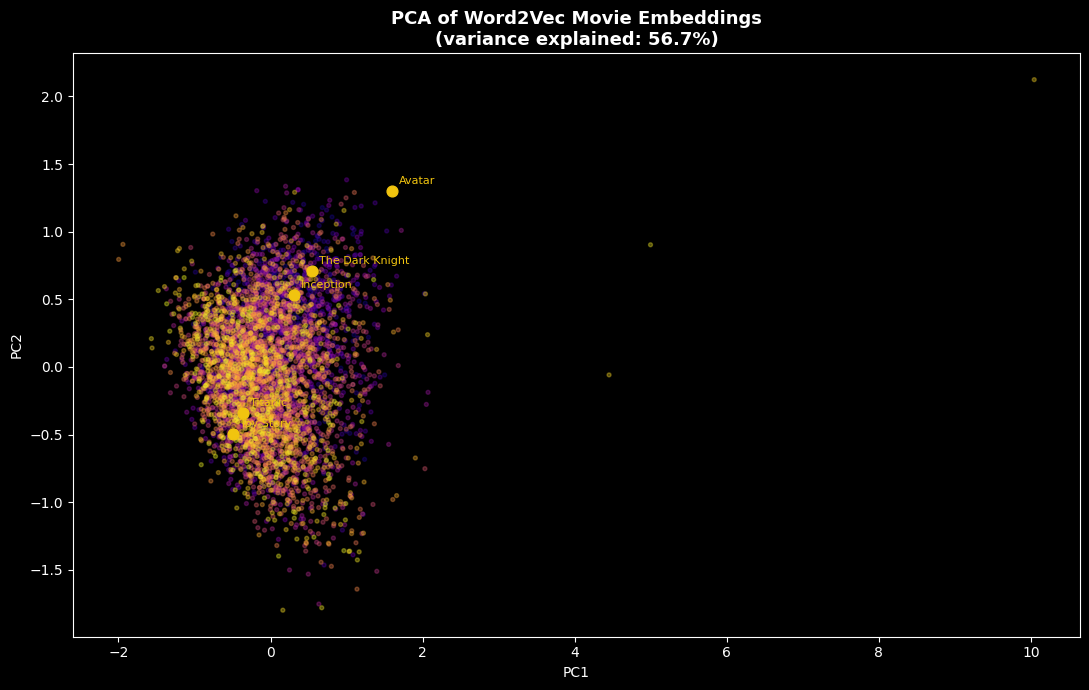

In [4]:
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(movie_matrix)
variance_explained = pca.explained_variance_ratio_.sum() * 100

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(reduced[:, 0], reduced[:, 1], alpha=0.35, s=8, c=range(len(df)), cmap='plasma')
ax.set_title(f'PCA of Word2Vec Movie Embeddings\n(variance explained: {variance_explained:.1f}%)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# Annotate a few known movies
highlight = ['Avatar', 'Toy Story', 'The Dark Knight', 'Titanic', 'Inception']
for title in highlight:
    idx = df[df['title'] == title].index
    if len(idx) > 0:
        i = df.index.get_loc(idx[0])
        ax.annotate(title, (reduced[i, 0], reduced[i, 1]),
                    fontsize=8, color='#f1c40f',
                    xytext=(5, 5), textcoords='offset points')
        ax.scatter(reduced[i, 0], reduced[i, 1], s=60, color='#f1c40f', zorder=5)

plt.tight_layout()
plt.savefig('../reports/figures/pca_word2vec.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Movie-to-Movie Cosine Similarity

Using the Word2Vec movie vectors, we can find movies similar to a given film. Cosine similarity measures the angle between two vectors — 1.0 means identical direction, 0.0 means unrelated.

In [5]:
def w2v_similar_movies(query_title, top_k=5):
    matches = df[df['title'].str.contains(query_title, case=False, na=False)]
    if matches.empty:
        print(f'Movie "{query_title}" not found.'); return
    idx = df.index.get_loc(matches.index[0])
    query_vec = movie_matrix[idx].reshape(1, -1)
    scores = cosine_similarity(query_vec, movie_matrix)[0]
    top_idx = scores.argsort()[::-1][1:top_k+1]
    print(f'Movies similar to "{matches.iloc[0]["title"]}":')
    for i in top_idx:
        print(f'  {df.iloc[i]["title"]:45s}  score: {scores[i]:.4f}')

w2v_similar_movies('Toy Story')
print()
w2v_similar_movies('The Dark Knight')
print()
w2v_similar_movies('Titanic')

Movies similar to "Toy Story 3":
  Barbecue                                       score: 0.9978
  When the Cat's Away                            score: 0.9976
  24 7: Twenty Four Seven                        score: 0.9969
  The SpongeBob SquarePants Movie                score: 0.9966
  Liar Liar                                      score: 0.9965

Movies similar to "The Dark Knight Rises":
  Now You See Me 2                               score: 0.9966
  Die Hard: With a Vengeance                     score: 0.9965
  The Skeleton Key                               score: 0.9964
  Conspiracy Theory                              score: 0.9964
  Man on a Ledge                                 score: 0.9954

Movies similar to "Titanic":
  Pink Ribbons, Inc.                             score: 0.9984
  Fifty Shades of Grey                           score: 0.9968
  Nowhere Boy                                    score: 0.9967
  The Prince & Me                                score: 0.9966
  The Nativ

## 5. Word Vector Arithmetic

A famous property of Word2Vec is analogical reasoning: `king − man + woman ≈ queen`. We test this on our movie domain.

In [6]:
analogies = [
    ('action', 'violence', 'comedy'),
    ('horror', 'fear', 'romance'),
]
for pos1, neg, pos2 in analogies:
    try:
        result = w2v_model.wv.most_similar(positive=[pos1, pos2], negative=[neg], topn=3)
        print(f'{pos1} - {neg} + {pos2} ≈ {[(w, round(s,3)) for w,s in result]}')
    except KeyError as e:
        print(f'Word not in vocabulary: {e}')

action - violence + comedy ≈ [('animation', 0.925), ('prehistoric', 0.914), ('adventure', 0.912)]
horror - fear + romance ≈ [('cavemen', 0.944), ('wales', 0.941), ('croods', 0.934)]


## Summary

| What | Result |
|------|--------|
| Model | Word2Vec (Skip-gram, Gensim) |
| Vocabulary | All unique words in movie corpus |
| Vector size | 100 dimensions per word |
| Movie representation | Mean of word vectors |
| Saved to | `models/word2vec.model`, `models/w2v_movie_embeddings.npy` |

**Limitation:** Word2Vec averages word vectors, which loses word order and sentence context. This is addressed in Notebook 04 with Sentence Transformers, which encode full sentences contextually.